In [1]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage import exposure

In [2]:
data_dir = "graphs_stereo"
pattern_size = (11, 8)
square_size = 14.5e-3 # mm

In [3]:
left_images = sorted(glob.glob(os.path.join(data_dir, "*_left.png")))
right_images = sorted(glob.glob(os.path.join(data_dir, "*_right.png")))
print("Found", len(left_images), "stereo pairs.")

Found 31 stereo pairs.


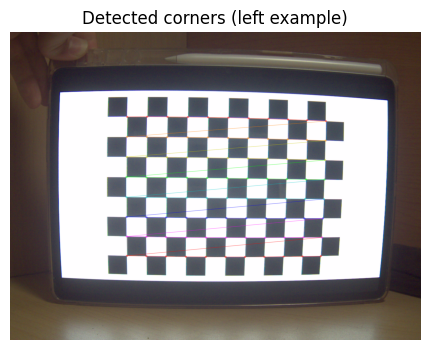

Detected valid corner pairs: 31


In [4]:
# Step 3: Detect chessboard corners
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
objp = np.zeros((pattern_size[1]*pattern_size[0], 3), np.float32)
objp[:, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)
objp *= square_size

obj_points, img_points_left, img_points_right = [], [], []

for left_path, right_path in zip(left_images, right_images):
    imgL = cv2.imread(left_path)
    grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    imgR = cv2.imread(right_path)
    grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
    retL, cornersL = cv2.findChessboardCorners(grayL, pattern_size)
    retR, cornersR = cv2.findChessboardCorners(grayR, pattern_size)
    if retL and retR:
        obj_points.append(objp)
        cornersL = cv2.cornerSubPix(grayL, cornersL, (11,11), (-1,-1), criteria)
        cornersR = cv2.cornerSubPix(grayR, cornersR, (11,11), (-1,-1), criteria)
        img_points_left.append(cornersL)
        img_points_right.append(cornersR)

# 显示一个示例角点检测结果
cv2.drawChessboardCorners(imgL, pattern_size, cornersL, True)
plt.figure(figsize=(6,4))
plt.title("Detected corners (left example)")
plt.imshow(cv2.cvtColor(imgL, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
print("Detected valid corner pairs:", len(obj_points))


In [5]:
# Step 4: Single camera calibration (Left and Right)
img_shape = cv2.imread(left_images[0]).shape[1::-1]

retL, mtxL, distL, rvecsL, tvecsL = cv2.calibrateCamera(obj_points, img_points_left, img_shape, None, None)
retR, mtxR, distR, rvecsR, tvecsR = cv2.calibrateCamera(obj_points, img_points_right, img_shape, None, None)

print("Left camera matrix:\n", mtxL)
print("Right camera matrix:\n", mtxR)
print("Left reprojection error:", retL)
print("Right reprojection error:", retR)

Left camera matrix:
 [[3.68446767e+03 0.00000000e+00 1.21306946e+03]
 [0.00000000e+00 3.68556573e+03 9.87612567e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Right camera matrix:
 [[3.66526541e+03 0.00000000e+00 1.23720871e+03]
 [0.00000000e+00 3.66672853e+03 9.70001539e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Left reprojection error: 0.4396549111349129
Right reprojection error: 0.40268044632829214


In [6]:
# Step 5: Stereo calibration
criteria_stereo = (cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS, 100, 1e-5)
retStereo, mtxL_s, distL_s, mtxR_s, distR_s, R, T, E, F = cv2.stereoCalibrate(
    obj_points, img_points_left, img_points_right,
    mtxL, distL, mtxR, distR, img_shape,
    criteria=criteria_stereo, flags=cv2.CALIB_FIX_INTRINSIC
)

print("Stereo calibration RMS error:", retStereo)
print("Rotation matrix R:\n", R)
print("Translation vector T:\n", T.ravel())

Stereo calibration RMS error: 0.6123953136398883
Rotation matrix R:
 [[ 0.99628164  0.00923885  0.08565946]
 [-0.00895663  0.99995312 -0.00367839]
 [-0.08568943  0.0028975   0.99631768]]
Translation vector T:
 [-0.07201193 -0.00019156  0.00238771]


In [7]:
# Step 6: Rectification and visualization
R1, R2, P1, P2, Q_cv, roi1, roi2 = cv2.stereoRectify(
    mtxL_s, distL_s, mtxR_s, distR_s, img_shape, R, T, alpha=0
)
print("Original OpenCV Q matrix:\n", Q_cv)
Q_1 = Q_cv[:, [0, 1, 3, 2]]
print("Modified Q matrix:\n", Q_1)
f = P1[0, 0]  # focal length in pixels
cx = P1[0, 2]
cy = P1[1, 2]
Tx = T[0][0]  # baseline in same units as object points (usually mm)

baseline = abs(Tx)

# ---- 构造Q矩阵（OpenCV文档标准形式）----
Q = np.float32([
    [1, 0, 0, -cx],
    [0, 1, 0, -cy],
    [0, 0, f, 0],
    [0, 0, 0, -1/baseline]
])
print("Refined Q matrix:\n", Q)

Original OpenCV Q matrix:
 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -1.17179587e+03]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -9.85306992e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  3.96935138e+03]
 [ 0.00000000e+00  0.00000000e+00  1.38789119e+01 -0.00000000e+00]]
Modified Q matrix:
 [[ 1.00000000e+00  0.00000000e+00 -1.17179587e+03  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00 -9.85306992e+02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  3.96935138e+03  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -0.00000000e+00  1.38789119e+01]]
Refined Q matrix:
 [[ 1.0000000e+00  0.0000000e+00  0.0000000e+00 -1.1717959e+03]
 [ 0.0000000e+00  1.0000000e+00  0.0000000e+00 -9.8530701e+02]
 [ 0.0000000e+00  0.0000000e+00  3.9693513e+03  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 -1.3886588e+01]]


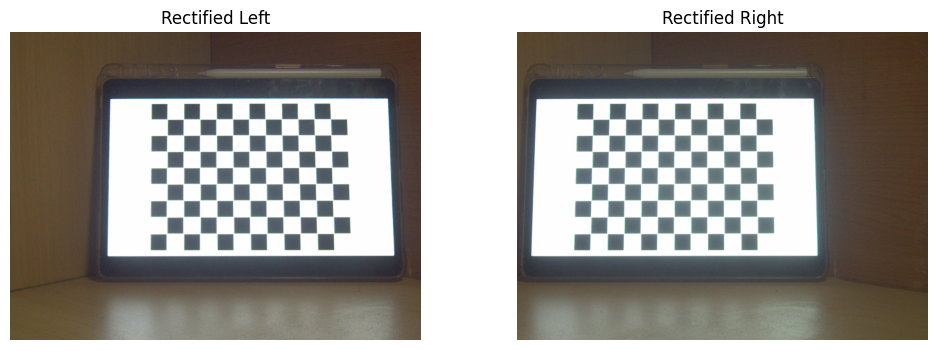

In [8]:
map1x, map1y = cv2.initUndistortRectifyMap(mtxL_s, distL_s, R1, P1, img_shape, cv2.CV_32FC1)
map2x, map2y = cv2.initUndistortRectifyMap(mtxR_s, distR_s, R2, P2, img_shape, cv2.CV_32FC1)
imgL = cv2.imread(left_images[0])
imgR = cv2.imread(right_images[0])
rectL = cv2.remap(imgL, map1x, map1y, cv2.INTER_LINEAR)
rectR = cv2.remap(imgR, map2x, map2y, cv2.INTER_LINEAR)

fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].imshow(cv2.cvtColor(rectL, cv2.COLOR_BGR2RGB))
axs[0].set_title("Rectified Left")
axs[1].imshow(cv2.cvtColor(rectR, cv2.COLOR_BGR2RGB))
axs[1].set_title("Rectified Right")
for ax in axs: ax.axis("off")
plt.show()


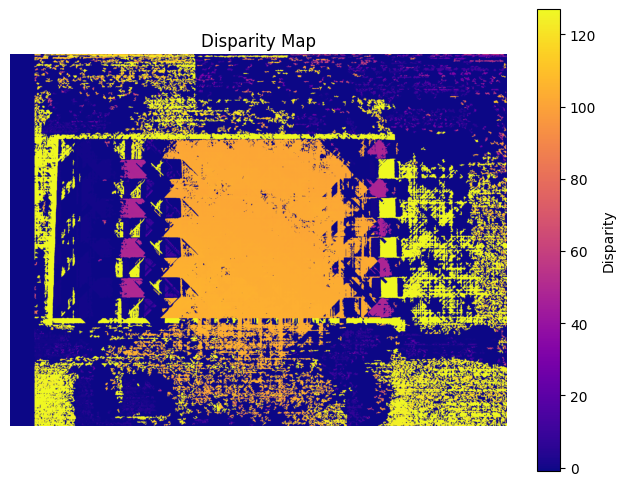

In [9]:
# Step 7: Compute disparity and 3D points
grayL = cv2.cvtColor(rectL, cv2.COLOR_BGR2GRAY)
grayR = cv2.cvtColor(rectR, cv2.COLOR_BGR2GRAY)

stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=16*8,
    blockSize=7,
    P1=8*3*7**2,
    P2=32*3*7**2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32
)

disp = stereo.compute(grayL, grayR).astype(np.float32) / 16.0
plt.figure(figsize=(8,6))
plt.imshow(disp, cmap='plasma')
plt.colorbar(label='Disparity')
plt.title("Disparity Map")
plt.axis("off")
plt.show()


In [10]:
points_3d = cv2.reprojectImageTo3D(disp, Q)
mask = (disp > 0) & np.isfinite(disp)
colors = cv2.cvtColor(rectL, cv2.COLOR_BGR2RGB)
pts = points_3d[mask]
cols = colors[mask]

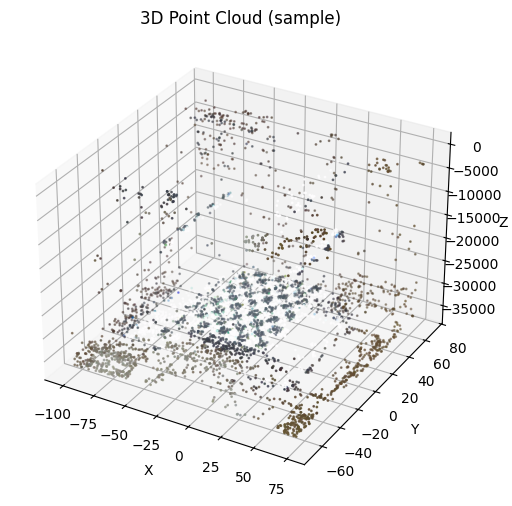

In [11]:
# Step 8: Visualize 3D point cloud in matplotlib
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
sample_idx = np.random.choice(len(pts), size=min(5000, len(pts)), replace=False)
ax.scatter(pts[sample_idx,0], pts[sample_idx,1], pts[sample_idx,2],
           c=cols[sample_idx]/255.0, s=1)
ax.set_title("3D Point Cloud (sample)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

In [12]:
def write_ply(fn, verts, colors):
    verts = verts.reshape(-1,3)
    colors = colors.reshape(-1,3)
    with open(fn, 'w') as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write("element vertex %d\n" % len(verts))
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\nproperty uchar blue\nend_header\n")
        for p, c in zip(verts, colors):
            f.write("%f %f %f %d %d %d\n" % (p[0], p[1], p[2]/100, int(c[0]), int(c[1]), int(c[2])))

In [13]:
# Step 9: Save results
np.savez("stereo_params.npz",
         mtxL=mtxL_s, distL=distL_s,
         mtxR=mtxR_s, distR=distR_s,
         R=R, T=T, E=E, F=F, Q=Q)
print("Saved stereo_params.npz")

write_ply("point_cloud.ply", pts, cols)
print("Saved point_cloud.ply with", pts.shape[0], "points")


Saved stereo_params.npz
Saved point_cloud.ply with 2141242 points


In [14]:
scenery_dir = "graphs_scenery"
scene_left_path = os.path.join(scenery_dir, "B_left.png")
scene_right_path = os.path.join(scenery_dir, "B_right.png")

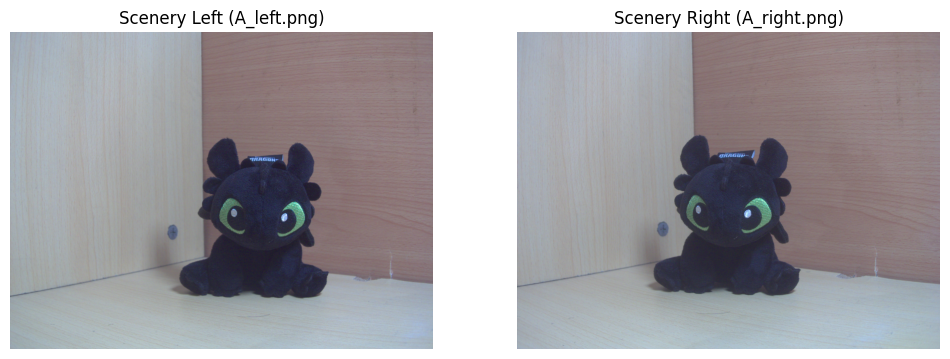

In [15]:
scene_imgL = cv2.imread(scene_left_path)
scene_imgR = cv2.imread(scene_right_path)

# 检查图像是否读取成功
if scene_imgL is None or scene_imgR is None:
    raise FileNotFoundError(f"未找到风景照，请确认路径：{scene_left_path} 和 {scene_right_path}")

# 显示原始风景照
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(cv2.cvtColor(scene_imgL, cv2.COLOR_BGR2RGB))
plt.title("Scenery Left (A_left.png)")
plt.axis("off")
plt.subplot(122)
plt.imshow(cv2.cvtColor(scene_imgR, cv2.COLOR_BGR2RGB))
plt.title("Scenery Right (A_right.png)")
plt.axis("off")
plt.show()

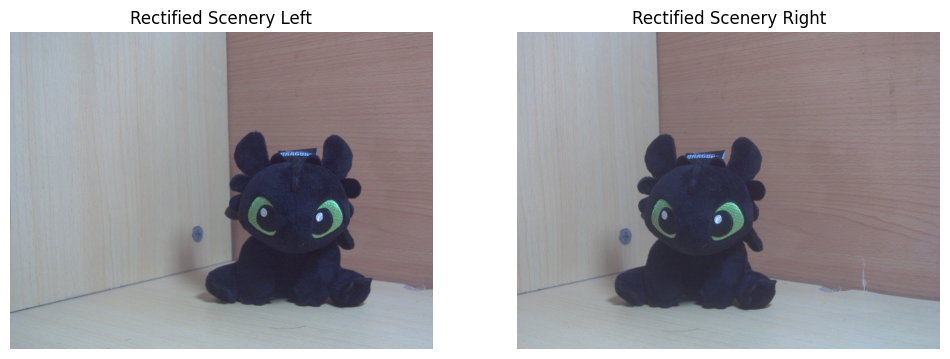

In [16]:
scene_rectL = cv2.remap(scene_imgL, map1x, map1y, cv2.INTER_LINEAR)  # 左图校正
scene_rectR = cv2.remap(scene_imgR, map2x, map2y, cv2.INTER_LINEAR)  # 右图校正

# 显示校正后的风景照（检查极线对齐效果）
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(cv2.cvtColor(scene_rectL, cv2.COLOR_BGR2RGB))
plt.title("Rectified Scenery Left")
plt.axis("off")
plt.subplot(122)
plt.imshow(cv2.cvtColor(scene_rectR, cv2.COLOR_BGR2RGB))
plt.title("Rectified Scenery Right")
plt.axis("off")
plt.show()

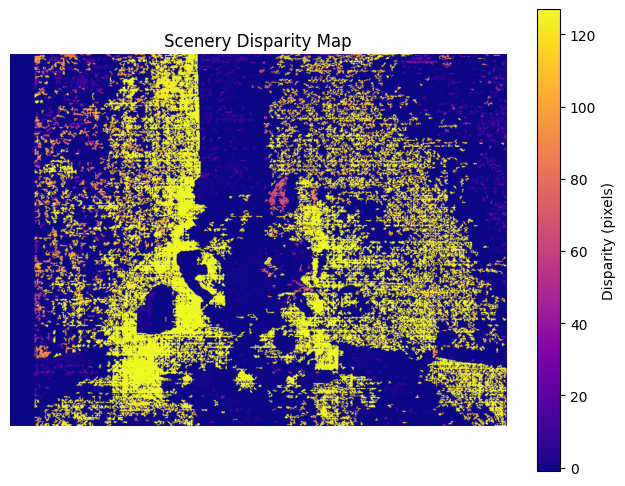

In [17]:
scene_grayL = cv2.cvtColor(scene_rectL, cv2.COLOR_BGR2GRAY)
scene_grayR = cv2.cvtColor(scene_rectR, cv2.COLOR_BGR2GRAY)

# 计算视差（注意：直接复用前面定义的stereo对象，参数一致）
scene_disp = stereo.compute(scene_grayL, scene_grayR).astype(np.float32) / 16.0

# 显示风景照视差图
plt.figure(figsize=(8, 6))
disp_plot = plt.imshow(scene_disp, cmap='plasma')
plt.colorbar(disp_plot, label='Disparity (pixels)')
plt.title("Scenery Disparity Map")
plt.axis("off")
plt.show()

风景照有效3D点数量：1572502


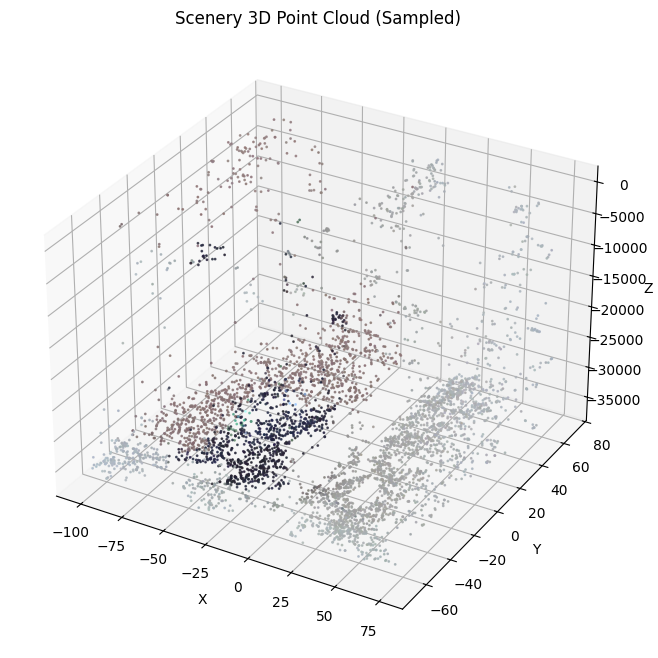

In [18]:
scene_points_3d = cv2.reprojectImageTo3D(scene_disp, Q)  # 复用前文的Q矩阵

# 过滤无效点（视差>0且有限）
scene_mask = (scene_disp > 0) & np.isfinite(scene_disp)
scene_pts = scene_points_3d[scene_mask]  # 有效3D坐标 (N, 3)
scene_colors = cv2.cvtColor(scene_rectL, cv2.COLOR_BGR2RGB)[scene_mask]  # 对应颜色 (N, 3)

print(f"风景照有效3D点数量：{len(scene_pts)}")


# %%
# 可视化风景照3D点云（采样显示，避免卡顿）
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 随机采样5000个点（若总点数不足则全显示）
sample_size = min(5000, len(scene_pts))
scene_sample_idx = np.random.choice(len(scene_pts), sample_size, replace=False)

# 绘制带颜色的点云
ax.scatter(
    scene_pts[scene_sample_idx, 0],  # X坐标
    scene_pts[scene_sample_idx, 1],  # Y坐标
    scene_pts[scene_sample_idx, 2],  # Z坐标（深度）
    c=scene_colors[scene_sample_idx] / 255.0,  # 颜色归一化
    s=1,  # 点大小
    alpha=0.8
)

ax.set_title("Scenery 3D Point Cloud (Sampled)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


# %%
# 保存风景照点云为PLY文件


In [19]:
write_ply("scenery_point_cloud.ply", scene_pts, scene_colors)
print(f"风景照点云已保存为：scenery_point_cloud.ply，包含 {len(scene_pts)} 个点")

风景照点云已保存为：scenery_point_cloud.ply，包含 1572502 个点
